# **Импорты**

In [ ]:
# Слои и модели Keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, MaxPooling2D, Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

# Вспомогательные библиотеки
import matplotlib.pyplot as plt
import numpy as np
import gdown
import os
import random
import time
from PIL import Image

# Модули контроля оперативной памяти (Критически важны для Lite-задания)
import gc
import tensorflow.keras.backend as K

# Настройка красивых графиков
import seaborn as sns
sns.set_style('darkgrid')

# **Загрузка данных**

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)

# Распаковываем файлы тихо без лишнего вывода
!unzip -qo construction_256x192.zip
print("Архив успешно распакован. На диске появились папки 'train' и 'val'.")

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:14<00:00, 14.7MB/s]


Архив успешно распакован. На диске появились папки 'train' и 'val'.


# **Задание параметров**

In [ ]:
# Размеры картинок в датасете
IMG_WIDTH = 192
IMG_HEIGHT = 256
TRAIN_DIRECTORY = 'train'
VAL_DIRECTORY = 'val'

# 16 оригинальных цветов разметки
FLOOR = (100, 100, 100); CEILING = (0, 0, 100); WALL = (0, 100, 0); COLUMN = (100, 0, 0)
APERTURE = (0, 100, 100); DOOR = (100, 0, 100); WINDOW = (100, 100, 0); EXTERNAL = (200, 200, 200)
RAILINGS = (0, 200, 0); BATTERY = (200, 0, 0); PEOPLE = (0, 200, 200); LADDER = (0, 0, 200)
INVENTORY = (200, 0, 200); LAMP = (200, 200, 0); WIRE = (0, 100, 200); BEAM = (100, 0, 200)

# Группировка 16 исходных классов в 5 новых макро-категорий по условию Lite-задания
class_0 = [WALL, COLUMN, BEAM]                             # Несущие элементы
class_1 = [FLOOR, CEILING]                                 # Перекрытия
class_2 = [APERTURE, DOOR, WINDOW]                         # Проемы, двери и окна
class_3 = [RAILINGS, BATTERY, LADDER, INVENTORY, LAMP, WIRE] # Коммуникации и внутренние объекты
class_4 = [EXTERNAL, PEOPLE]                               # Внешний мир и люди

def rgb_to_5_labels(image_list):
    result = []
    for img in image_list:
        sample = np.array(img)
        # Одноканальная разреженная матрица (вместо прожорливого One-Hot)
        y = np.zeros((IMG_WIDTH, IMG_HEIGHT, 1), dtype='uint8')

        for cl in class_0: y[np.where(np.all(sample == cl, axis=-1))] = 0
        for cl in class_1: y[np.where(np.all(sample == cl, axis=-1))] = 1
        for cl in class_2: y[np.where(np.all(sample == cl, axis=-1))] = 2
        for cl in class_3: y[np.where(np.all(sample == cl, axis=-1))] = 3
        for cl in class_4: y[np.where(np.all(sample == cl, axis=-1))] = 4
        result.append(y)
    return np.array(result)

def read_raw_images(base_dir, sub_dir):
    path = os.path.join(base_dir, sub_dir)
    return [image.load_img(os.path.join(path, f), target_size=(IMG_WIDTH, IMG_HEIGHT)) for f in sorted(os.listdir(path))]

print("Загрузка и конвертация оригинальных фото...")
raw_train_images = read_raw_images(TRAIN_DIRECTORY, 'original')
raw_val_images = read_raw_images(VAL_DIRECTORY, 'original')

x_train = np.array([image.img_to_array(img) for img in raw_train_images], dtype='float32') / 255.0
x_val = np.array([image.img_to_array(img) for img in raw_val_images], dtype='float32') / 255.0

# Моментально вычищаем списки-дубликаты оригиналов из памяти
del raw_train_images, raw_val_images
gc.collect()

print("Загрузка и конвертация цветных масок в 5 категорий...")
raw_train_segments = read_raw_images(TRAIN_DIRECTORY, 'segment')
raw_val_segments = read_raw_images(VAL_DIRECTORY, 'segment')

y_train_sparse = rgb_to_5_labels(raw_train_segments)
y_val_sparse = rgb_to_5_labels(raw_val_segments)

# Моментально вычищаем списки-дубликаты масок из памяти
del raw_train_segments, raw_val_segments
gc.collect()

print("\n--- ДАННЫЕ УСПЕШНО СФОРМИРОВАНЫ С ЗАЩИТОЙ ОТ СБОЯ ОЗУ ---")
print("Размер обучающих картинок x_train:", x_train.shape)
print("Размер экономичных масок y_train_sparse (1 канал вместо 5):", y_train_sparse.shape)

Загрузка и конвертация оригинальных фото...
Загрузка и конвертация цветных масок в 5 категорий...

--- ДАННЫЕ УСПЕШНО СФОРМИРОВАНЫ С ЗАЩИТОЙ ОТ СБОЯ ОЗУ ---
Размер обучающих картинок x_train: (1900, 192, 256, 3)
Размер экономичных масок y_train_sparse (1 канал вместо 5): (1900, 192, 256, 1)


# **Функция параметризации**

In [ ]:
def create_parameterized_simple_unet(input_shape, filters, kernel_size, activation_func):
    inputs = Input(input_shape)

    # Плечо сжатия (Энкодер)
    conv1 = Conv2D(filters, (kernel_size, kernel_size), activation=activation_func, padding='same')(inputs)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    # Горлышко (Bottleneck)
    conv2 = Conv2D(filters * 2, (kernel_size, kernel_size), activation=activation_func, padding='same')(pool1)

    # Плечо восстановления (Декодер)
    up3 = Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding='same')(conv2)
    merge3 = concatenate([conv1, up3], axis=3) # Skip connection
    conv3 = Conv2D(filters, (kernel_size, kernel_size), activation=activation_func, padding='same')(merge3)

    # Финальный слой выдает 5 каналов (по числу наших укрупненных классов)
    outputs = Conv2D(5, (1, 1), activation='softmax', padding='same')(conv3)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# **Задаем гиперпараметры и обучаем НС**

In [ ]:
# Описываем конфигурации для 10 различных экспериментов по условию ТЗ
experiments_config = [
    {"filters": 16, "kernel": 3, "activation": "relu"},       # 1. Базовый
    {"filters": 32, "kernel": 3, "activation": "relu"},       # 2. Увеличение фильтров
    {"filters": 64, "kernel": 3, "activation": "relu"},       # 3. Еще больше фильтров
    {"filters": 32, "kernel": 5, "activation": "relu"},       # 4. Увеличение ядра до 5x5
    {"filters": 32, "kernel": 7, "activation": "relu"},       # 5. Увеличение ядра до 7x7
    {"filters": 32, "kernel": 3, "activation": "linear"},     # 6. Активация linear
    {"filters": 32, "kernel": 3, "activation": "selu"},       # 7. Активация selu
    {"filters": 32, "kernel": 3, "activation": "elu"},        # 8. Активация elu
    {"filters": 16, "kernel": 5, "activation": "elu"},        # 9. Комбинация ядра 5 и elu
    {"filters": 64, "kernel": 5, "activation": "selu"}        # 10. Тяжелая комбинация признаков
]

# Словари для сохранения финальных результатов
history_logs = {}
final_accuracies = {}

EPOCHS_COUNT = 7
BATCH_SIZE = 8  # Пониженный размер пакета гарантирует, что Colab не выбросит OOM

for idx, config in enumerate(experiments_config, 1):
    print(f"\n=================== СТАРТ ЭКСПЕРИМЕНТА №{idx}/10 ===================")
    print(f"Конфигурация: Фильтры={config['filters']}, Ядро={config['kernel']}, Активация={config['activation']}")

    # Шаг Жесткой Очистки ОЗУ перед инициализацией модели
    K.clear_session()
    gc.collect()
    time.sleep(1) # Короткая микропауза для стабильности ОС

    # Строим параметризованную модель
    model = create_parameterized_simple_unet((IMG_WIDTH, IMG_HEIGHT, 3),
                                             config['filters'],
                                             config['kernel'],
                                             config['activation'])

    # Компилируем под разреженную кросс-энтропию (Sparse)
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Запуск обучения на 7 эпох
    history = model.fit(x_train, y_train_sparse,
                        epochs=EPOCHS_COUNT,
                        batch_size=BATCH_SIZE,
                        validation_data=(x_val, y_val_sparse),
                        verbose=1)

    # Сохраняем логи точности для последующего построения графиков
    exp_label = f"Эксп {idx} (F:{config['filters']}, K:{config['kernel']}, {config['activation']})"
    history_logs[exp_label] = history.history['val_accuracy']
    final_accuracies[exp_label] = history.history['val_accuracy'][-1]

    print(f"Эксперимент {idx} успешно завершен. Val Accuracy: {final_accuracies[exp_label]:.4f}")

    # Шаг Жесткой Очистки ОЗУ после завершения итерации
    del model
    del history
    K.clear_session()
    gc.collect()

print("\n\nВСЕ 10 ЭКСПЕРИМЕНТОВ ВЫПОЛНЕНЫ УСПЕШНО БЕЗ ПЕРЕПОЛНЕНИЯ ПАМЯТИ!")


=================== СТАРТ ЭКСПЕРИМЕНТА №1/10 ===================
Конфигурация: Фильтры=16, Ядро=3, Активация=relu
Epoch 1/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.4148 - loss: 1.4134 - val_accuracy: 0.5294 - val_loss: 1.2342
Epoch 2/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5273 - loss: 1.2537 - val_accuracy: 0.5294 - val_loss: 1.2011
Epoch 3/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5273 - loss: 1.2015 - val_accuracy: 0.5294 - val_loss: 1.1811
Epoch 4/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5275 - loss: 1.1669 - val_accuracy: 0.5303 - val_loss: 1.1619
Epoch 5/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5326 - loss: 1.1455 - val_accuracy: 0.5316 - val_loss: 1.1523
Epoch 6/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5383 - loss: 1.1334 - val_accuracy: 0.5358 - val_loss: 1.1462
Epoch 7/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5421 - loss: 1.1249 - val_accuracy: 0.5375 - val_l

# **Визуализация**

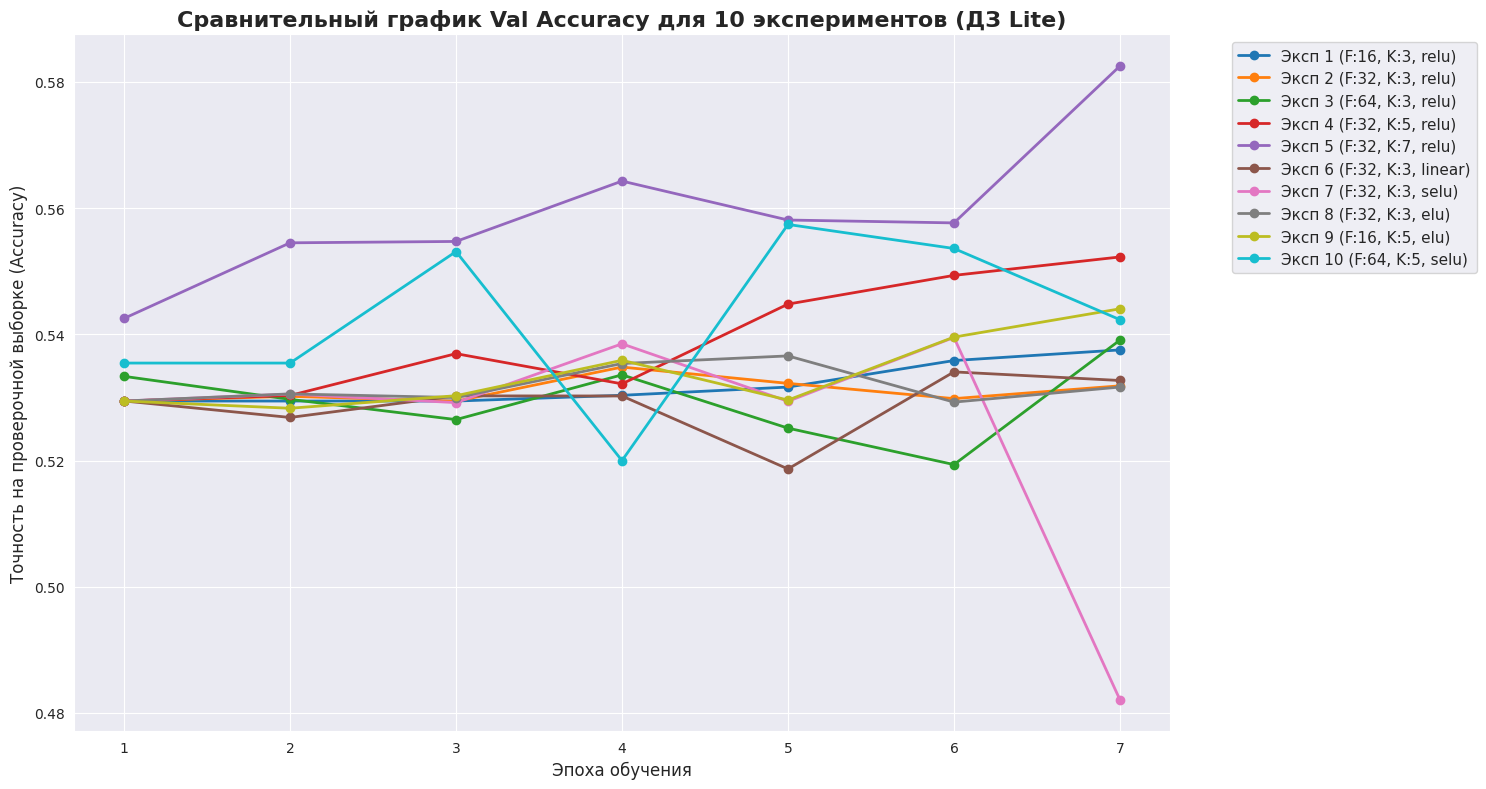


Рейтинг моделей по финальной точности на валидации:
Место 1: Эксп 5 (F:32, K:7, relu) -> 0.5825
Место 2: Эксп 4 (F:32, K:5, relu) -> 0.5523
Место 3: Эксп 9 (F:16, K:5, elu) -> 0.5440
Место 4: Эксп 10 (F:64, K:5, selu) -> 0.5423
Место 5: Эксп 3 (F:64, K:3, relu) -> 0.5391
Место 6: Эксп 1 (F:16, K:3, relu) -> 0.5375
Место 7: Эксп 6 (F:32, K:3, linear) -> 0.5327
Место 8: Эксп 2 (F:32, K:3, relu) -> 0.5318
Место 9: Эксп 8 (F:32, K:3, elu) -> 0.5316
Место 10: Эксп 7 (F:32, K:3, selu) -> 0.4821


In [ ]:
# Настройка размеров холста графиков
plt.figure(figsize=(15, 8))

# Рисуем линии изменения точности по эпохам для каждого эксперимента
for label, accuracy_trend in history_logs.items():
    plt.plot(range(1, EPOCHS_COUNT + 1), accuracy_trend, marker='o', label=label, linewidth=2)

plt.title('Сравнительный график Val Accuracy для 10 экспериментов (ДЗ Lite)', fontsize=16, fontweight='bold')
plt.xlabel('Эпоха обучения', fontsize=12)
plt.ylabel('Точность на проверочной выборке (Accuracy)', fontsize=12)
plt.xticks(range(1, EPOCHS_COUNT + 1))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

# Печатаем текстовый рейтинг моделей от лучшей к худшей
print("\nРейтинг моделей по финальной точности на валидации:")
sorted_rating = sorted(final_accuracies.items(), key=lambda item: item[1], reverse=True)
for rank, (name, acc) in enumerate(sorted_rating, 1):
    print(f"Место {rank}: {name} -> {acc:.4f}")